# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Scikit-Learn
from sklearn.linear_model import Perceptron #used for simple classification tasks
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

#TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout #Dropout prevents the overfitting
from tensorflow.keras.utils import to_categorical

# Load Dataset

In [3]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df_test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


# Data Preprocessing and Feature Scaling

In [7]:
df.shape

(60000, 785)

In [8]:
df_test.shape

(10000, 785)

In [9]:
# Preprocessing
X_train = df.drop('label',axis=1).values
y_train = df['label'].values
X_test = df_test.drop('label',axis=1).values
y_test = df_test['label'].values
# here the value converts the pd Dataframe to numpy array list 

In [10]:
# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
# dividing the date by 255.0 normalizes the range to 0-1

In [11]:
#Reshape the preprocess data
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [12]:
# scaling the target values
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10) # probablities of 10 classes

In [13]:
print(X_train_img.shape)
print(y_train_cat.shape)

print(X_test_img.shape)
print(y_test_cat.shape)

(60000, 28, 28)
(60000, 10)
(10000, 28, 28)
(10000, 10)


# Perceptron Architecture

fs,djashf

In [14]:
# Initializing the nueron layer by layer
per = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')  #output neurons
])
per.compile(optimizer='sgd', loss='categorical_crossentropy',metrics=['accuracy'])

### Training Phase

In [15]:
hist_per = per.fit(X_train_img, y_train_cat,
                   validation_data=(X_test_img,y_test_cat),
                   batch_size=32,epochs=10,verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7386 - loss: 0.8278 - val_accuracy: 0.7964 - val_loss: 0.6385
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8051 - loss: 0.5945 - val_accuracy: 0.8139 - val_loss: 0.5672
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8196 - loss: 0.5459 - val_accuracy: 0.8260 - val_loss: 0.5331
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8264 - loss: 0.5196 - val_accuracy: 0.8317 - val_loss: 0.5113
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8308 - loss: 0.5022 - val_accuracy: 0.8381 - val_loss: 0.4989
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8347 - loss: 0.4895 - val_accuracy: 0.8386 - val_loss: 0.4885
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8369 - loss: 0.4800 - val_accuracy: 0.8410 - val_loss: 0.4814
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8394 - loss: 0.4722 - 

In [16]:
#finding th accuracy
acc_per = per.evaluate(X_test_img,y_test_cat,verbose=0)[1]
acc_per

0.8457000255584717

### Visualization

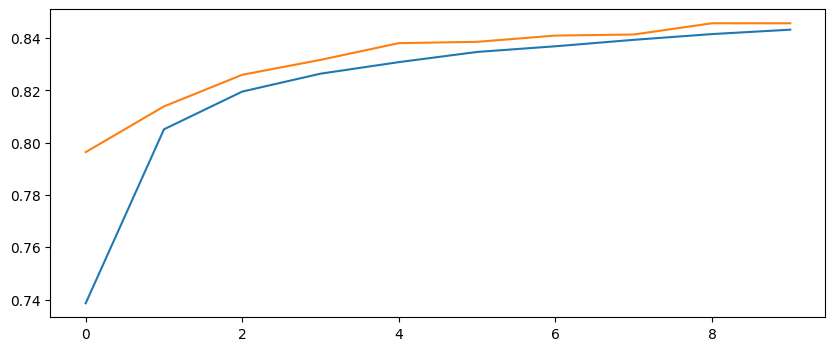

In [17]:
plt.figure(figsize=(10,4))
plt.plot(hist_per.history['accuracy'],label="Accurcay")
plt.plot(hist_per.history['val_accuracy'],label="Validation Accuracy")

# ANN 

In [18]:
# Conversion of 2d(Image) to 1d(Vector) for the ANN
X_train_ann = X_train.reshape(-1, 784)
X_test_ann = X_test.reshape(-1, 784)

In [19]:
ann = Sequential([
    Flatten(input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [20]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

### Training Phase

In [21]:
hist_ann = ann.fit(X_train_ann, y_train_cat,
                   validation_data=(X_test_ann, y_test_cat),
                                    batch_size=32,epochs=10,verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8224 - loss: 0.4961 - val_accuracy: 0.8572 - val_loss: 0.3989
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8639 - loss: 0.3743 - val_accuracy: 0.8753 - val_loss: 0.3422
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8769 - loss: 0.3385 - val_accuracy: 0.8748 - val_loss: 0.3300
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8831 - loss: 0.3169 - val_accuracy: 0.8771 - val_loss: 0.3293
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8887 - loss: 0.2990 - val_accuracy: 0.8870 - val_loss: 0.3062
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8943 - loss: 0.2835 - val_accuracy: 0.8811 - val_loss: 0.3182
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8990 - loss: 0.2710 - val_accuracy: 0.8864 - val_loss: 0.3052
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9028 - loss: 0.2599 - 

In [22]:
acc_ann = ann.evaluate(X_test_ann, y_test_cat, verbose=0)[1] #here the [1] -accurcay
acc_ann

0.8931000232696533

# CNN 

In [23]:
#reshape 
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [24]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [25]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

### Training Phase

In [26]:
hist_cnn = cnn.fit(X_train_cnn, y_train_cat,
                   validation_data=(X_test_cnn,y_test_cat),
                   batch_size=32,epochs=5,verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.7861 - loss: 0.5922 - val_accuracy: 0.8632 - val_loss: 0.3831
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.8557 - loss: 0.4107 - val_accuracy: 0.8839 - val_loss: 0.3168
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.8717 - loss: 0.3553 - val_accuracy: 0.8934 - val_loss: 0.2877
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8847 - loss: 0.3239 - val_accuracy: 0.9016 - val_loss: 0.2645
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8928 - loss: 0.2980 - val_accuracy: 0.9058 - val_loss: 0.2565


In [27]:
acc_cnn = cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]
acc_cnn

0.9057999849319458

### Visualization

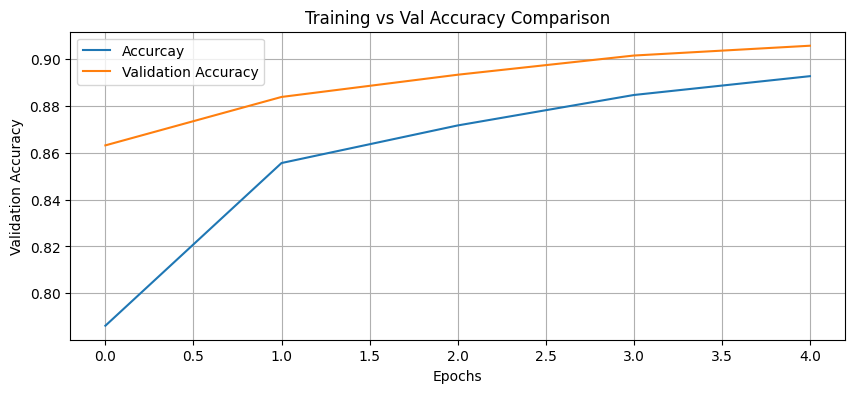

In [28]:
plt.figure(figsize=(10,4))
plt.plot(hist_cnn.history['accuracy'],label="Accurcay")
plt.plot(hist_cnn.history['val_accuracy'],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Training vs Val Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

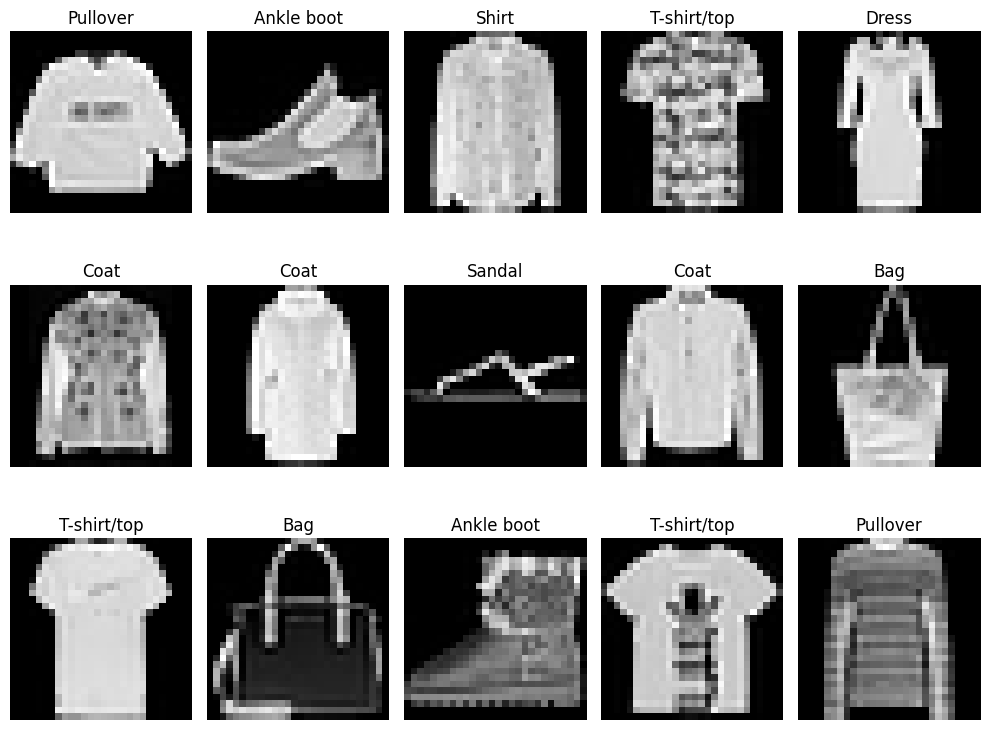

In [29]:
#Visualization of the first 15 images in the dataset
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
plt.figure(figsize=(10, 8))
for i in range(15):
    plt.subplot(3, 5, i+1)
    img = df.iloc[i, 1:].values.reshape(28, 28)
    label_index = df.iloc[i, 0]
    
    plt.imshow(img, cmap='gray')
    plt.title(class_names[label_index])
    plt.axis('off')

plt.tight_layout()
plt.show()